In [12]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [1]:
import matplotlib.pyplot as plt 
from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import pickle 
import pandas as pd 
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


In [2]:
from sheap import Sheapectral
from sheap.Utils.SpectralReaders import parallel_reader 

from sheap.Utils.Paper import plot_logdex_agreement,log10_to_linear,posterior_extraction,bins_centered_on_zero,summary_similarity
from sheap.Assistants.parser_mapper import get_multiple_sample_params,get_sample_params,summarize_spectral_lines

In [5]:
base_panda = pd.read_csv(f"../pickle_spectra/{"paula_binB"}.csv")

In [6]:
base_panda

,SDSS_name,spec_name,lc_name,ra,dec,zspec,PLATE,MJD,FIBERID,DR,...,abs_fit_CIV,logBHmass,logBHmass_err,logMDOT,logMDOT_err,final_mass_line,dr_name,fit_path,zbin,npix
0,021450.21-050819.7,spec_33.709220_-5.138822.txt,bin3_onechip_33.709220_-5.138822_XMM_LSS,33.709220,-5.138822,0.451226,7237.0,56662.0,235.0,12,...,NaN,8.022147,0.029297,-0.706295,0.035689,Halpha+Hbeta,7237-56662-0235,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4622
1,022039.48-030820.3,spec_35.164534_-3.138978.txt,bin3_onechip_35.164534_-3.138978_XMM_LSS,35.164534,-3.138978,0.451887,6369.0,56217.0,586.0,12,...,NaN,7.998189,0.009807,-0.177863,0.009673,Halpha+Hbeta,6369-56217-0586,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4586
2,021103.17-041425.0,spec_32.763250_-4.240281.txt,bin3_onechip_32.763250_-4.240281_XMM_LSS,32.763250,-4.240281,0.458385,7237.0,56662.0,550.0,12,...,NaN,7.230426,0.034378,-0.970703,0.040369,Halpha+Hbeta,7237-56662-0550,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4598
3,095915.20+031617.4,spec_149.813370_3.271520.txt,bin3_onechip_149.813370_3.271520_COSMOS,149.813370,3.271520,0.460900,572.0,52289.0,128.0,7,...,NaN,-99.000000,-99.000000,-99.000000,-99.000000,NaN,0572-52289-0128,/home/favila/data_2/dr16/paula_spectras/0572-5...,binB,3844
4,022258.90-045852.4,spec_35.745432_-4.981234.txt,bin3_onechip_35.745432_-4.981234_XMM_LSS,35.745432,-4.981234,0.466177,6369.0,56217.0,298.0,12,...,NaN,7.617653,0.019522,-0.965380,0.026248,Halpha+Hbeta,6369-56217-0298,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,021227.63-040635.8,spec_33.115137_-4.109966.txt,bin3_onechip_33.115137_-4.109966_XMM_LSS,33.115137,-4.109966,0.784461,7237.0,56662.0,600.0,12,...,NaN,7.844619,0.035198,-0.850256,0.043761,MgII,7237-56662-0600,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4599
147,023246.82-050136.6,spec_38.195096_-5.026859.txt,bin3_onechip_38.195096_-5.026859_XMM_LSS,38.195096,-5.026859,0.787910,7235.0,56603.0,112.0,12,...,NaN,8.553557,0.079170,-1.235743,0.085116,MgII,7235-56603-0112,/home/favila/data_2/dr16/paula_spectras/7235-5...,binB,4628
148,022340.16-025534.0,spec_35.917373_-2.926116.txt,bin3_onechip_35.917373_-2.926116_XMM_LSS,35.917373,-2.926116,0.792172,6369.0,56217.0,781.0,12,...,NaN,8.025075,0.070308,-1.312272,0.079246,MgII,6369-56217-0781,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4586
149,020517.38-051024.0,spec_31.322444_-5.173335.txt,bin3_onechip_31.322444_-5.173335_XMM_LSS,31.322444,-5.173335,0.792485,7238.0,56660.0,723.0,12,...,NaN,7.775754,0.050580,-1.590111,0.058980,MgII,7238-56660-0723,/home/favila/data_2/dr16/paula_spectras/7238-5...,binB,4596


In [7]:
sheapspectral = Sheapectral.from_pickle("SS18B_montecarlo_rachi.pkl")

In [8]:
# sheapspectral.result.outer_limits

In [9]:
summary = summarize_spectral_lines(sheapspectral.result.region_list)

=== SpectralLine summary ===
Counts by region:
  - balmer: 2
  - broad: 2
  - outflow: 2
  - continuum: 1
  - fe: 1
  - host: 1
  - narrow: 1

Gaussian-ish entries (profile/subprofile contains 'gaussian'): 5
Gaussian-ish by region:
  - broad: 2
  - outflow: 2
  - narrow: 1

Continuum components:
  - continuum / continuum1 (profile: powerlaw)

Line mappings (region / component):
  - broad / broad1: 12 lines
      Hε - 3970.072
      Hδ - 4101.742
      HeIIb - 2733.290
      HeIa - 2945.106
      HeIb - 3187.745
      HeIIc - 3203.100
      HeIc - 4143.761
      Hg - 4340.471
      HeId - 4471.479
      HeIId - 4685.710
      Hbeta - 4861.333
      MgII - 2799.000
  - broad / broad2: 12 lines
      Hε - 3970.072
      Hδ - 4101.742
      HeIIb - 2733.290
      HeIa - 2945.106
      HeIb - 3187.745
      HeIIc - 3203.100
      HeIc - 4143.761
      Hg - 4340.471
      HeId - 4471.479
      HeIId - 4685.710
      Hbeta - 4861.333
      MgII - 2799.000
  - narrow / narrow1: 18 lines
      

array([<Axes: xlabel='Redshift (z)', ylabel='Number of objects'>,
       <Axes: xlabel='Mean Signal-to-Noise Ratio'>], dtype=object)

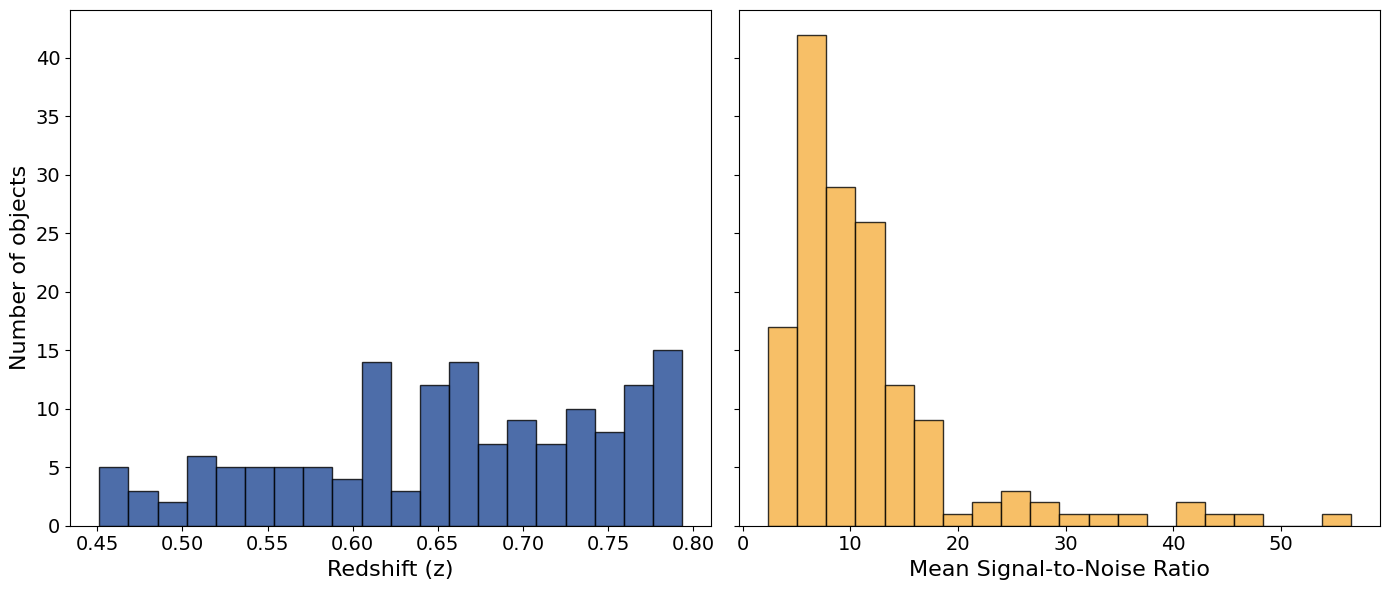

In [10]:
sheapspectral.plot_redshift_signal2noise_distribution

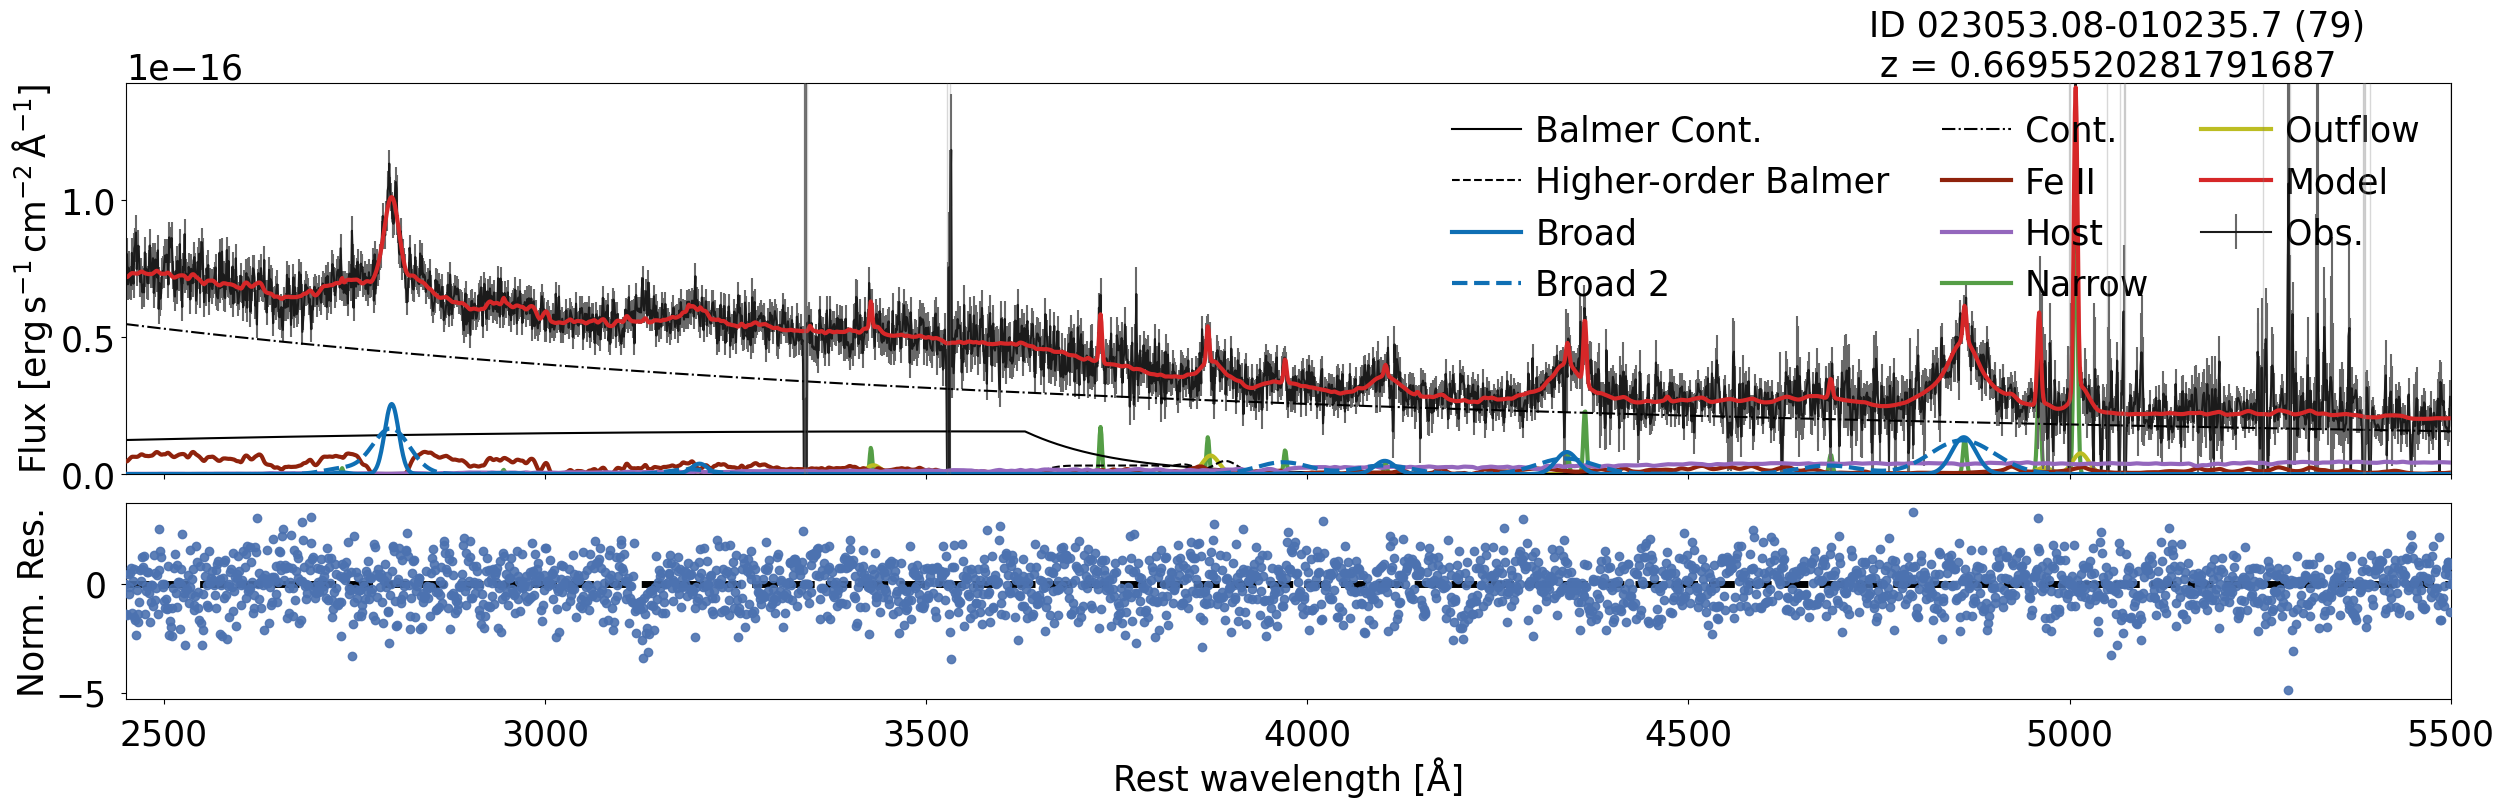

In [11]:
sheapspectral.modelplot.plot(79,add_legend=True,add_lines_name=False)

In [13]:
#  'REDSHIFT',
#        'RMAG', 'EW_DAS', 'EW_DAS_ERR', 'FWHM_DAS', 'FWHM_DAS_ERR', 'RFE_DAS',
#        'RFE_DAS_ERR', 'L3000_DAS', 'L3000_DAS_ERR', 'LOGMASS_DAS_PAN25',
#        'LOGMASS_DAS_PAN25_ERR', 'LOGMASS_DAS_VO09', 'LOGMASS_DAS_VO09_ERR',
#        'LOGMASS_DAS_SHEN11', 'LOGMASS_DAS_SHEN11_ERR', 'LOGMASS_DAS_LE20',
#        'LOGMASS_DAS_LE20_ERR', 'LOGMASS_DAS_YU23', 'LOGMASS_DAS_YU23_ERR',
#        'L3000_FSF', 'FWHM_FSF', 'LOGMASS_FSF_VO09', 'path'],

In [14]:
# sheapspectral.result.posterior[1]["021450.21-050819.7"]["extra_combined_params"]["MgII"]["MR16_global_MgII_L3000_FWHM"]["Lwave"]

In [15]:
# MgII_FWHM = pd.DataFrame([{"name": key,**values["extra_combined_params"]["MgII"]["MR16_global_MgII_L3000_FWHM"]["vwidth_kms"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
from sheap.Assistants.parser_mapper import get_multiple_sample_params,get_sample_params,summarize_spectral_lines

In [16]:
df_extra = posterior_extraction(
     sheapspectral,
     posterior_idx=1,
     extra_key="extra_params_combined_classical",
 )

mask = (
    (df_extra["line"] == "Hbeta") &
    (df_extra["SMBHEstimator"] == "MR16_local_Hbeta_L5100_FWHM") &
    (df_extra["quantity"] == "vwidth_kms")
)

Hbeta_FWHM_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
Hbeta_FWHM_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
Hbeta_FWHM_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

mask = (
    (df_extra["line"] == "Hbeta") &
    (df_extra["SMBHEstimator"] == "MR16_local_Hbeta_L5100_FWHM") &
    (df_extra["quantity"] == "Lwave")
)

Hbeta_Lwave_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
Hbeta_Lwave_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
Hbeta_Lwave_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

mask = (
    (df_extra["line"] == "MgII") &
    (df_extra["SMBHEstimator"] == "MR16_global_MgII_L3000_FWHM") &
    (df_extra["quantity"] == "vwidth_kms")
)

MgII_FWHM_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
MgII_FWHM_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
MgII_FWHM_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

mask = (
    (df_extra["line"] == "MgII") &
    (df_extra["SMBHEstimator"] == "MR16_global_MgII_L3000_FWHM") &
    (df_extra["quantity"] == "Lwave")
)

MgII_Lwave_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
MgII_Lwave_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
MgII_Lwave_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

####################################################

#MR16_local_Hbeta_L5100 =  pd.DataFrame([{"name": key,**values["extra_combined_params"]["Hbeta"]["MR16_local_Hbeta_L5100_FWHM"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values


FWHM_Hbeta,FWHM_Hbeta_err_minus,FWHM_Hbeta_err_plus = log10_to_linear(base_panda.logFWHM_Hbeta.values,base_panda.logFWHM_Hbeta_err.values)
FWHM_MgII,FWHM_MgII_err_minus,FWHM_MgII_err_plus = log10_to_linear(base_panda.logFWHM_MgII.values,base_panda.logFWHM_MgII_err.values)
Lcont_Hbeta,Lcont_Hbeta_err_minus,Lcont_Hbeta_err_plus = log10_to_linear(base_panda.logLcont_Hbeta.values,base_panda.logLcont_Hbeta_err.values)
Lcont_MgII,Lcont_MgII_err_minus,Lcont_MgII_err_plus = log10_to_linear(base_panda.logLcont_MgII.values,base_panda.logLcont_MgII_err.values)
# #FWHM_MgII = 10**base_panda.logFWHM_MgII.values
# Lcont_MgII = 10**base_panda.logLcont_MgII.values
# logBHmass_Hbeta = base_panda.logBHmass_Hbeta.values

/share/cav/data/favila/smbh_mass/sheap/sheap/Utils/Paper.py:159: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [17]:
# np.array(Lcont_MgII).shape

In [18]:
base_panda

,SDSS_name,spec_name,lc_name,ra,dec,zspec,PLATE,MJD,FIBERID,DR,...,abs_fit_CIV,logBHmass,logBHmass_err,logMDOT,logMDOT_err,final_mass_line,dr_name,fit_path,zbin,npix
0,021450.21-050819.7,spec_33.709220_-5.138822.txt,bin3_onechip_33.709220_-5.138822_XMM_LSS,33.709220,-5.138822,0.451226,7237.0,56662.0,235.0,12,...,NaN,8.022147,0.029297,-0.706295,0.035689,Halpha+Hbeta,7237-56662-0235,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4622
1,022039.48-030820.3,spec_35.164534_-3.138978.txt,bin3_onechip_35.164534_-3.138978_XMM_LSS,35.164534,-3.138978,0.451887,6369.0,56217.0,586.0,12,...,NaN,7.998189,0.009807,-0.177863,0.009673,Halpha+Hbeta,6369-56217-0586,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4586
2,021103.17-041425.0,spec_32.763250_-4.240281.txt,bin3_onechip_32.763250_-4.240281_XMM_LSS,32.763250,-4.240281,0.458385,7237.0,56662.0,550.0,12,...,NaN,7.230426,0.034378,-0.970703,0.040369,Halpha+Hbeta,7237-56662-0550,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4598
3,095915.20+031617.4,spec_149.813370_3.271520.txt,bin3_onechip_149.813370_3.271520_COSMOS,149.813370,3.271520,0.460900,572.0,52289.0,128.0,7,...,NaN,-99.000000,-99.000000,-99.000000,-99.000000,NaN,0572-52289-0128,/home/favila/data_2/dr16/paula_spectras/0572-5...,binB,3844
4,022258.90-045852.4,spec_35.745432_-4.981234.txt,bin3_onechip_35.745432_-4.981234_XMM_LSS,35.745432,-4.981234,0.466177,6369.0,56217.0,298.0,12,...,NaN,7.617653,0.019522,-0.965380,0.026248,Halpha+Hbeta,6369-56217-0298,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,021227.63-040635.8,spec_33.115137_-4.109966.txt,bin3_onechip_33.115137_-4.109966_XMM_LSS,33.115137,-4.109966,0.784461,7237.0,56662.0,600.0,12,...,NaN,7.844619,0.035198,-0.850256,0.043761,MgII,7237-56662-0600,/home/favila/data_2/dr16/paula_spectras/7237-5...,binB,4599
147,023246.82-050136.6,spec_38.195096_-5.026859.txt,bin3_onechip_38.195096_-5.026859_XMM_LSS,38.195096,-5.026859,0.787910,7235.0,56603.0,112.0,12,...,NaN,8.553557,0.079170,-1.235743,0.085116,MgII,7235-56603-0112,/home/favila/data_2/dr16/paula_spectras/7235-5...,binB,4628
148,022340.16-025534.0,spec_35.917373_-2.926116.txt,bin3_onechip_35.917373_-2.926116_XMM_LSS,35.917373,-2.926116,0.792172,6369.0,56217.0,781.0,12,...,NaN,8.025075,0.070308,-1.312272,0.079246,MgII,6369-56217-0781,/home/favila/data_2/dr16/paula_spectras/6369-5...,binB,4586
149,020517.38-051024.0,spec_31.322444_-5.173335.txt,bin3_onechip_31.322444_-5.173335_XMM_LSS,31.322444,-5.173335,0.792485,7238.0,56660.0,723.0,12,...,NaN,7.775754,0.050580,-1.590111,0.058980,MgII,7238-56660-0723,/home/favila/data_2/dr16/paula_spectras/7238-5...,binB,4596


Bad errors plus in index [  2   3   5   6   7  10  11  13  18  22  23  24  25  30  31  35  39  45
  47  48  49  54  58  59  60  77  81  87  88  95  97 112 114 143], replacing per 100% error
Bad errors minus in index [  2   3   5   6   7  10  11  13  18  22  23  24  25  30  31  35  39  45
  47  48  49  54  58  59  60  77  81  87  88  95  97 112 114 143] 100% error


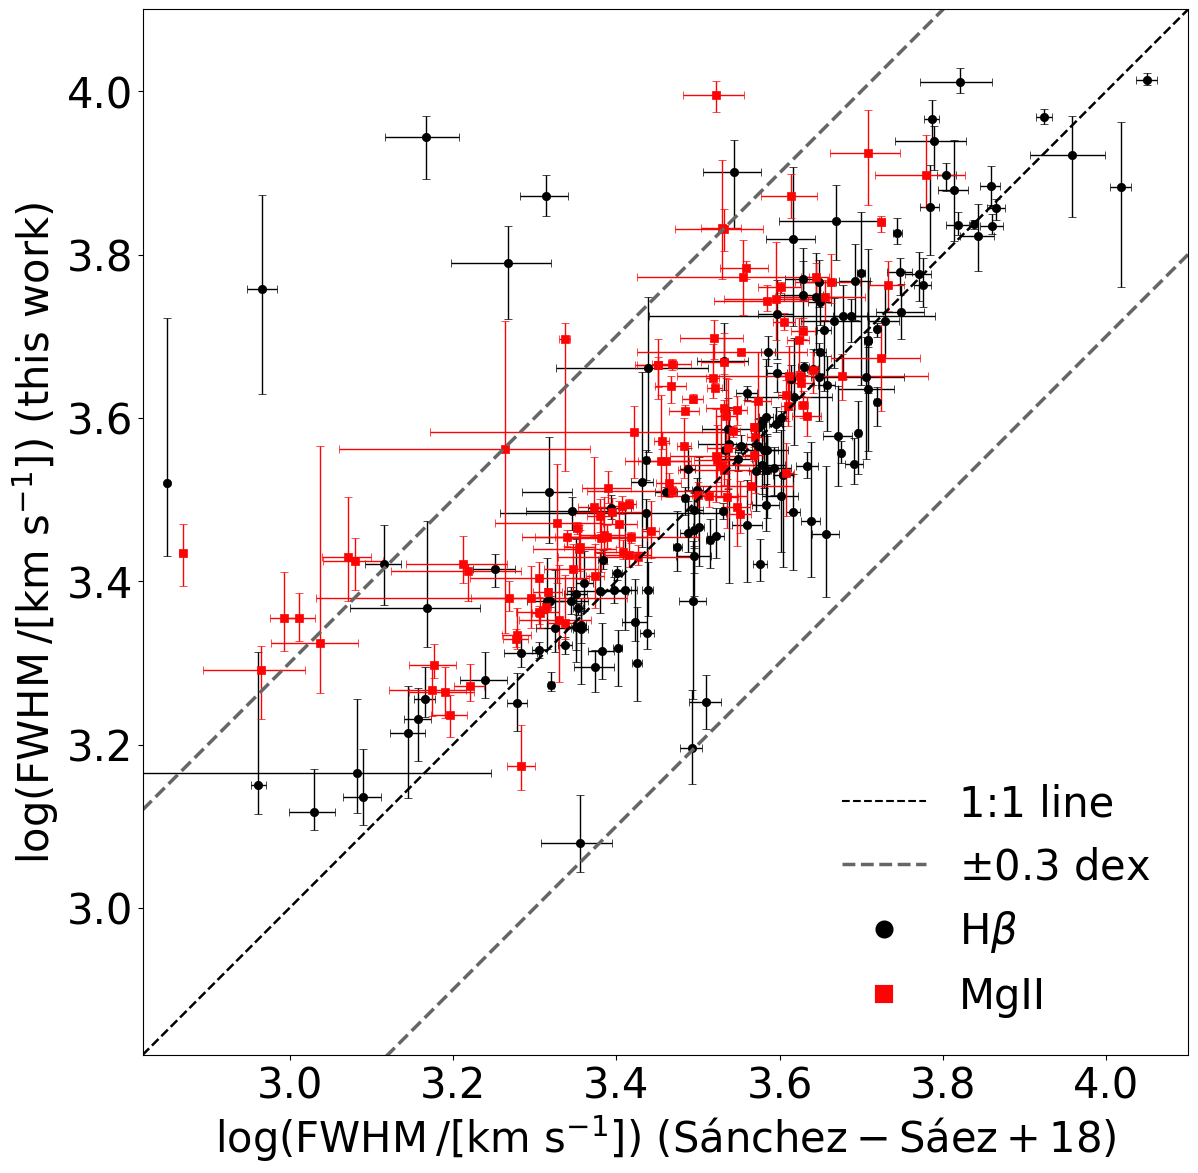

In [19]:
data_dict = {
	r"H$\beta$": {
		"x": np.vstack([FWHM_Hbeta,FWHM_Hbeta_err_minus,FWHM_Hbeta_err_plus]),          # (2, N) symmetric error
		"y": np.vstack([Hbeta_FWHM_median,Hbeta_FWHM_err_plus,Hbeta_FWHM_err_minus]),  # (3, N) +/-
	},
	r"MgII": {
		"x": np.vstack([FWHM_MgII,FWHM_MgII_err_minus,FWHM_MgII_err_plus]),          # (2, N) symmetric error
		"y": np.vstack([MgII_FWHM_median,MgII_FWHM_err_plus,MgII_FWHM_err_minus]),  # (3, N) +/-
	},}
sn = None #sheapspectral.snr
(_,_,fwhm,_)=plot_logdex_agreement(data_dict,lims=[2.82,4.1],ref_label="",label_mode="fwhm_clasic",ref_work="Sánchez-Sáez+18",add_numbers=False,sn=sn,label_colorbar="S/N",save_file="images/fwhm_compare_SS18.pdf")#)

Bad errors minus in index [103 122 150] 100% error
Bad errors plus in index [  2   3   5   6   7  10  11  13  18  22  23  24  25  30  31  35  39  45
  47  48  49  54  58  59  60  77  81  87  88  95  97 112 114 143], replacing per 100% error
Bad errors minus in index [  2   3   5   6   7  10  11  13  18  22  23  24  25  30  31  35  39  45
  47  48  49  54  58  59  60  77  81  87  88  95  97 112 114 143] 100% error


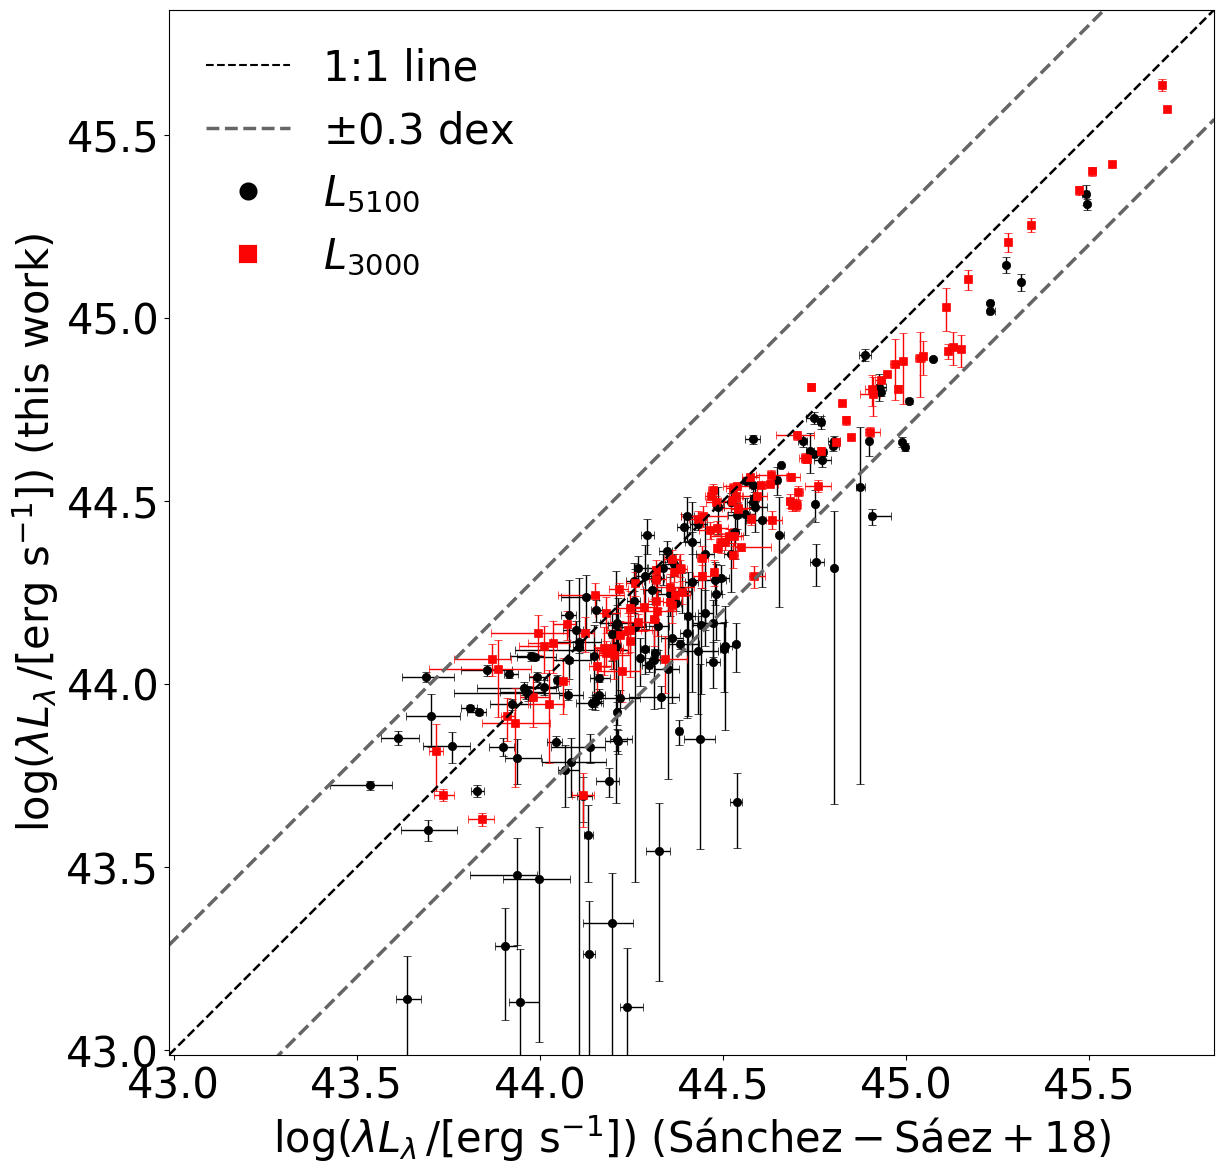

In [20]:
data_dict = {r"$L_{5100}$": {
		"x": np.vstack([Hbeta_Lwave_median,Hbeta_Lwave_err_minus,Hbeta_Lwave_err_plus]),          # (2, N) symmetric error
		"y": np.vstack([Lcont_Hbeta,Lcont_Hbeta_err_minus,Lcont_Hbeta_err_plus]),  # (3, N) +/-
	},
	r"$L_{3000}$": {
		"x": np.vstack([MgII_Lwave_median,MgII_Lwave_err_minus,MgII_Lwave_err_plus]),          # (2, N) symmetric error
		"y": np.vstack([Lcont_MgII,Lcont_MgII_err_minus,Lcont_MgII_err_plus ]),  # (3, N) +/-
	},
	}
save_file = "images/lcont_compare_SS18.pdf"
sn = None #sheapspectral.snr
(_,_,L,_)=plot_logdex_agreement(data_dict,ref_label="",label_mode="lcont_ww_classic",ref_work="Sánchez-Sáez+18",sn=sn,add_numbers=False,legend_loc="upper left",save_file=save_file,label_colorbar="S/N")


In [22]:
dictionaries = [fwhm, L]
for i in dictionaries:
	print(i.keys())

dict_keys(['H$\\beta$', 'MgII'])
dict_keys(['$L_{5100}$', '$L_{3000}$'])


In [24]:
# [val for d in dictionaries for k in main_key_list for val in [d.get(k, {}).get("res")] if val is not None][0].ravel()#.shape

In [25]:
# val

FWHM$_{\rm H\,\beta}$: N=151, band=±0.300 dex, f_within=95.364, bias_med=0.012 dexNMAD=0.078 dex SHEAP larger in 2.89%
FWHM$_{\rm Mg\,II}$: N=117, band=±0.300 dex, f_within=92.308, bias_med=0.080 dexNMAD=0.079 dex SHEAP larger in 20.29%
$L_{5100}$: N=151, band=±0.300 dex, f_within=77.483, bias_med=-0.133 dexNMAD=0.174 dex SHEAP smaller in 26.35%
$L_{3000}$: N=117, band=±0.300 dex, f_within=99.145, bias_med=-0.097 dexNMAD=0.071 dex SHEAP smaller in 19.98%


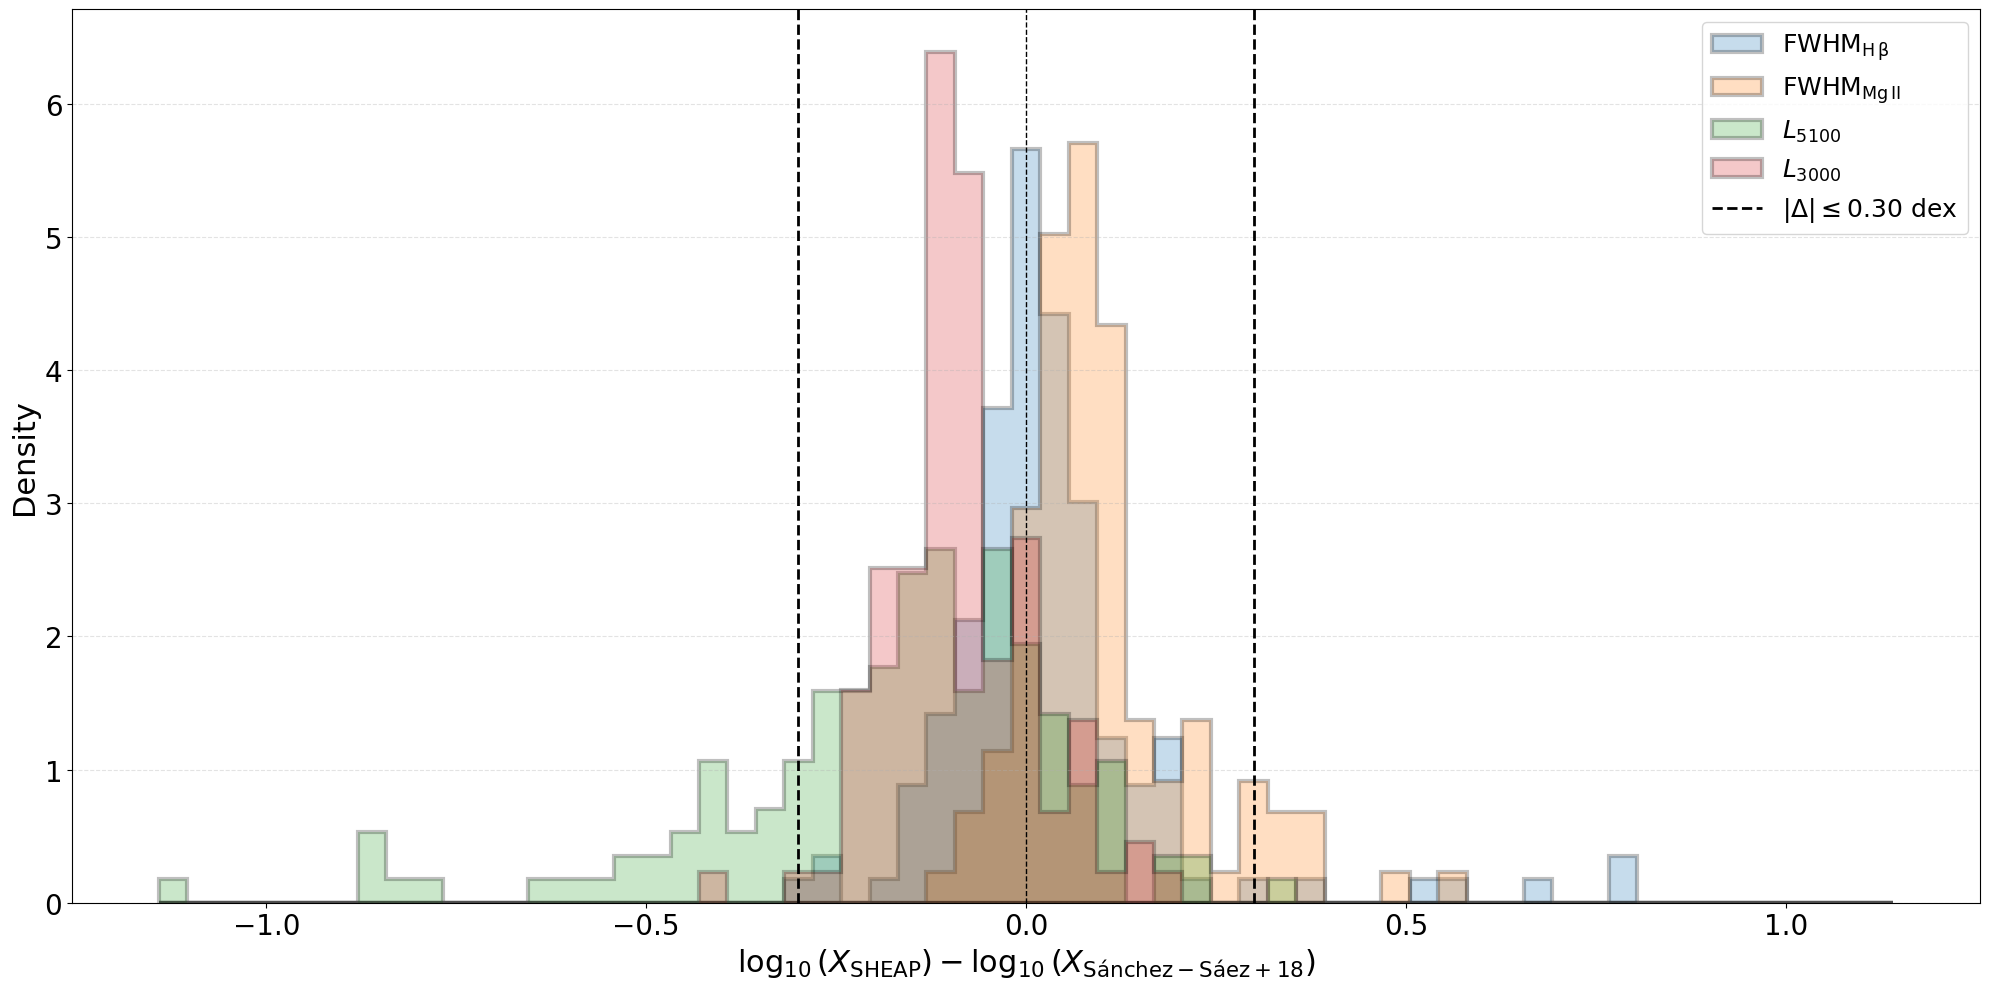

In [26]:
from matplotlib.lines import Line2D
FS = 22          # <- change this to scale everything
TICK_FS = FS - 2
LEGEND_FS = FS - 4
TITLE_FS = FS + 2

labels_p = [r"FWHM$_{\rm H\,\beta}$",r"FWHM$_{\rm Mg\,II}$",r"$L_{5100}$",r"$L_{3000}$"]
main_key_list = ['H$\\beta$', 'MgII','$L_{5100}$', '$L_{3000}$']
compared_xlabel = "Sánchez-Sáez+18"
#dictionaries = [lalpha, l5100, haFWHM,stars]
#labels = [r"$L_{H\alpha}$",r"$L_{5100}$",r"FWHM$_{H\alpha}$",r"(Star/Cont)$_{5100}$"]


density = True
nbins = 60

chunks = []

for d in dictionaries:
    for k in main_key_list:
        res = d.get(k, {}).get("res")
        if res is None:
            continue

        # use .sqe if it exists, otherwise use the value itself
        x = getattr(res, "sqe", res)

        # make array and flatten to 1D (handles scalar / list / any dimension)
        chunks.append(np.asarray(x).ravel())

all_x = np.concatenate(chunks) if chunks else np.array([])

edges = bins_centered_on_zero(all_x, nbins=nbins, clip=None)
bands = [val
	 for d in dictionaries
	 for k in main_key_list
	 for val in [d.get(k, {}).get("band")]
	 if val is not None]
band = max(bands)
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
jeje = 0 
for nn,D in enumerate(dictionaries):
	X = [val for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	sub_label = [k for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	for ii,x in enumerate(X):
		s_local = labels_p[jeje]
		local_ = s_local #sub_label[ii].replace("values","")
		print(summary_similarity(D[sub_label[ii]], name=local_))
		ax.hist(
			x,
			bins=edges,
			density=density,
			histtype="stepfilled",
			linewidth=3.0,
			edgecolor="black",
			alpha=0.25,   # lower alpha helps a lot
			label=local_,)
		jeje += 1
ax.axvline(0.0, linestyle="--", linewidth=1.0, color="k")
ax.axvline(+band, linestyle="--", linewidth=2.0, color="k")
ax.axvline(-band, linestyle="--", linewidth=2.0, color="k")
s = rf"$\log_{{10}}(X_{{\rm SHEAP}}) - \log_{{10}}(X_{{\rm {compared_xlabel}}})$"
ax.set_xlabel(s,fontsize=FS)

ax.set_ylabel("Density" if density else "Count", fontsize=FS)

# ticks + grid
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.tick_params(axis="both", which="minor", labelsize=TICK_FS - 2)
ax.grid(axis="y", linestyle="--", alpha=0.35)

# legend entries
handles, labels = ax.get_legend_handles_labels()
band_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
					label=rf"$|\Delta|\leq {band:.2f}\ \mathrm{{dex}}$")
# (optional) show zero separately
# zero_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
#                      label=r"$\Delta=0$")

ax.legend(
	handles + [band_handle],
	labels + [band_handle.get_label()],
	fontsize=LEGEND_FS,
	frameon=True
)
max_val = np.max(np.abs(ax.get_xlim()))
ax.set_xlim(-max_val,max_val)
fig.savefig("images/res_distribution.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.tight_layout()

In [27]:
labels_p

['FWHM$_{\\rm H\\,\\beta}$',
 'FWHM$_{\\rm Mg\\,II}$',
 '$L_{5100}$',
 '$L_{3000}$']

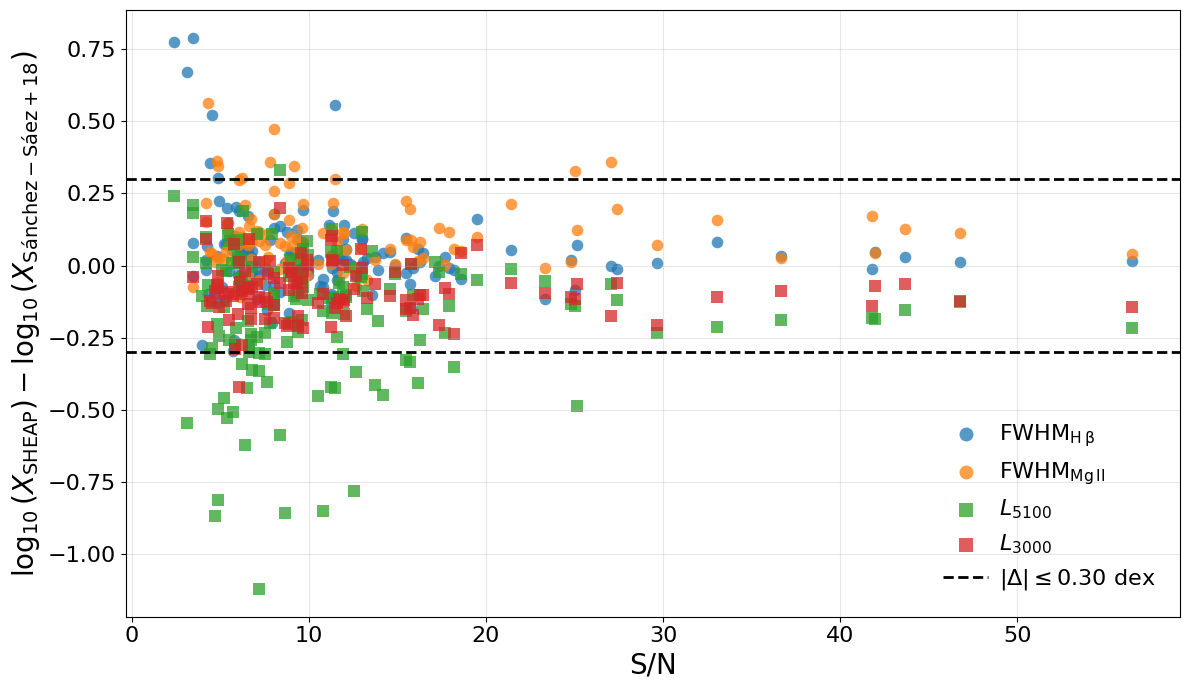

: 

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

#main_key = "Values Pan+25"
#labels_p = [r"FWHM$_{\rm Mg\,II}$",r"$L_{3000}$",r"$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$"]
#main_key_list = ["DAS values","FSF values",'FSF (h=0.7)',"DAS"]
markers = ["o", "s", "^", "D", "D", "D"]

# --- Font / style knobs ---
fs_label  = 20
fs_ticks  = 16
fs_legend = 16
marker_size = 70
alpha_val = 0.75

# --- Collect exactly-plotted data here ---
plot_data = {}  # plot_data[label] = {"x": x_plotted, "y": y_plotted}

fig, ax = plt.subplots(figsize=(12, 7))
jj = 0 
for nn, D in enumerate(dictionaries):
	#res = dd[main_key]["res"]
	X = [val for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	mask = [val for k in main_key_list for val in [D.get(k, {}).get("is_finite")] if val is not None]
	sub_label = [k for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	#s_local = labels_p[nn]
	for ii,res in enumerate(X):
		s_local = labels_p[jj]
  		#local_ = sub_label[ii].replace("values","")
		#print(summary_similarity(D[sub_label[ii]], name=f"{s_local} {local_}"))
		x_plot = sheapspectral.snr[mask[ii]]
		y_plot = res
		plot_data[s_local] = {
		"x": x_plot,
		"y": y_plot,
		"marker": markers[nn],
		#"main_key": main_key,
		}

		ax.scatter(
			x_plot, y_plot,
			marker=markers[nn],
			s=marker_size,
			alpha=alpha_val,
			label=s_local,
			linewidths=0.0
		)
		jj += 1
	#snr_local = sheapspectral.snr#[mask_local]

	#if len(res) != len(snr_local):
	 #   raise ValueError(f"Length mismatch: res={len(res)} vs snr_local={len(snr_local)}")

	#ok = np.isfinite(snr_local) & np.isfinite(res)

	# these are the ONLY points that go to the scatter


	

ax.axhline(0.3, linestyle="--", linewidth=2,c="k")
ax.axhline(-0.3, linestyle="--", linewidth=2,c="k",label=rf"$|\Delta|\leq {0.3:.2f}\ \mathrm{{dex}}$")

ax.set_xlabel("S/N", fontsize=fs_label)
ax.set_ylabel(r"$\log_{10}(X_{\rm SHEAP}) - \log_{10}(X_{\rm Sánchez-Sáez+18})$", fontsize=fs_label)
ax.tick_params(axis="both", which="major", labelsize=fs_ticks)
ax.tick_params(axis="both", which="minor", labelsize=fs_ticks - 2)
ax.grid(True, alpha=0.3)

ax.legend(
	fontsize=fs_legend,
	frameon=False,
	loc="best",
	markerscale=1.2,
	handletextpad=0.5,
	borderpad=0.6
)

plt.tight_layout()
plt.savefig("images/signal_2_noise_vs_res_sanche.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()

# --- Save the plotted x/y to pickle ---
os.makedirs("images", exist_ok=True)
pkl_path = "images/signal_2_noise_vs_res_sanche.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(plot_data, f, protocol=pickle.HIGHEST_PROTOCOL)

#print(f"Saved plotted x/y to: {pkl_path}")
